Project 2 

Research Question: 
Which factors influence whether or not a social media post goes "viral".
For this question viral is defined as above average engagement. Viral in this question will be based off of the average engagement for the entire data set. However another way to determine it is to user dat from just one user's account. This way viral can be more specific for the user as a user with under 500 followers and a user with 5 million followers have different standards for what is viral to them.


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV,  StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc
from ucimlrepo import fetch_ucirepo
# Import Packages


Section 1: Loading Data

In [2]:
df = pd.read_csv('/Users/bizyc/Downloads/Instagram_Analytics.csv')

In [3]:
df

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,5,brand,10739,carousel,Travel,Reels Feed,0,2024-12-18 10:00:00,2024-12-18,...,1,2,5,1564,2493,0.0032,124,127,8,low
29995,IG0029996,3,brand,10018,image,Beauty,Hashtags,0,2025-05-05 15:00:00,2025-05-05,...,2,1,7,2042,2492,0.0209,310,114,12,low
29996,IG0029997,18,creator,7486,image,Photography,Explore,1,2025-05-26 10:00:00,2025-05-26,...,10,16,59,5887,7528,0.0558,223,115,4,high
29997,IG0029998,6,creator,10034,carousel,Technology,Explore,1,2025-08-02 19:00:00,2025-08-02,...,3,0,19,5372,6312,0.0333,978,124,4,medium


There are 29999 rows ( the number starts at 0 instead of 1) and 23 columns.
The data set contains integers and strings.
The target variable I will be using is engagement_rate.

In [4]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

post_id:
 post_id
IG0000001    1
IG0019996    1
IG0020008    1
IG0020007    1
IG0020006    1
            ..
IG0009996    1
IG0009995    1
IG0009994    1
IG0009993    1
IG0029999    1
Name: count, Length: 29999, dtype: int64

account_id:
 account_id
13    1599
15    1599
17    1572
16    1569
4     1530
19    1517
12    1508
10    1502
5     1498
18    1494
3     1493
9     1480
20    1473
7     1472
8     1472
2     1471
1     1462
6     1452
14    1444
11    1392
Name: count, dtype: int64

account_type:
 account_type
creator    20944
brand       9055
Name: count, dtype: int64

follower_count:
 follower_count
5824     1599
8167     1599
15923    1572
9696     1569
4972     1530
3447     1517
13798    1508
4542     1502
10739    1498
7486     1494
10018    1493
6916     1480
31095    1473
3551     1472
15986    1472
22291    1471
9461     1462
10034    1452
3083     1444
9044     1392
Name: count, dtype: int64

media_type:
 media_type
image       11927
carousel    10627
reel         744

In [5]:
df.drop(columns = ['post_date', 'post_hour', 'post_datetime','account_id','post_id', 'account_type', 'media_type', 'traffic_source', 'day_of_week', 'content_category', 'performance_bucket_label'], inplace = True)

Dropping the post_date, post_hour, day_of_week colummns becausebecause I have decided not to use any of the categories that had to do with dates or days.
I dropped the post_id column because the because it was repetitve with another column. 
I removed account_type type because while it could be used in the different model not how I intend to use this one.
I removed media_type because the type of media is not significant for this model.
I removed traffic_source because post can appear on all traffic sources numerous times.
I removed content_category and performance_bucket_label while they could be useful but for this model and how I am using it and other varriables they are not useful.

In [6]:
df

,follower_count,has_call_to_action,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
0,3551,1,194,5,7,34,4327,6230,0.0385,899,100,7
1,31095,1,449,10,21,68,7451,8268,0.0663,805,122,5
2,8167,0,114,2,1,22,1639,2616,0.0531,758,115,8
3,9044,0,91,0,7,0,2877,3171,0.0309,402,115,7
4,15986,0,154,8,5,21,5350,8503,0.0221,155,112,9
...,...,...,...,...,...,...,...,...,...,...,...,...
29994,10739,0,0,1,2,5,1564,2493,0.0032,124,127,8
29995,10018,0,42,2,1,7,2042,2492,0.0209,310,114,12
29996,7486,1,335,10,16,59,5887,7528,0.0558,223,115,4
29997,10034,1,188,3,0,19,5372,6312,0.0333,978,124,4


In [7]:
# Use the dataframe already loaded from the CSV (df) instead of fetching a non-existent UC Irvine dataset
# Drop identifier and the target column from features
X = df.drop(columns=['engagement_rate'])
y = df['engagement_rate']

In [8]:
X

,follower_count,has_call_to_action,likes,comments,shares,saves,reach,impressions,followers_gained,caption_length,hashtags_count
0,3551,1,194,5,7,34,4327,6230,899,100,7
1,31095,1,449,10,21,68,7451,8268,805,122,5
2,8167,0,114,2,1,22,1639,2616,758,115,8
3,9044,0,91,0,7,0,2877,3171,402,115,7
4,15986,0,154,8,5,21,5350,8503,155,112,9
...,...,...,...,...,...,...,...,...,...,...,...
29994,10739,0,0,1,2,5,1564,2493,124,127,8
29995,10018,0,42,2,1,7,2042,2492,310,114,12
29996,7486,1,335,10,16,59,5887,7528,223,115,4
29997,10034,1,188,3,0,19,5372,6312,978,124,4


In [9]:
y

0        0.0385
1        0.0663
2        0.0531
3        0.0309
4        0.0221
          ...  
29994    0.0032
29995    0.0209
29996    0.0558
29997    0.0333
29998    0.0100
Name: engagement_rate, Length: 29999, dtype: float64

In [10]:
y.head()

0    0.0385
1    0.0663
2    0.0531
3    0.0309
4    0.0221
Name: engagement_rate, dtype: float64

Section 2: Data Cleaning

In [11]:
X.isnull().sum()

follower_count        0
has_call_to_action    0
likes                 0
comments              0
shares                0
saves                 0
reach                 0
impressions           0
followers_gained      0
caption_length        0
hashtags_count        0
dtype: int64

In [12]:
df

,follower_count,has_call_to_action,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
0,3551,1,194,5,7,34,4327,6230,0.0385,899,100,7
1,31095,1,449,10,21,68,7451,8268,0.0663,805,122,5
2,8167,0,114,2,1,22,1639,2616,0.0531,758,115,8
3,9044,0,91,0,7,0,2877,3171,0.0309,402,115,7
4,15986,0,154,8,5,21,5350,8503,0.0221,155,112,9
...,...,...,...,...,...,...,...,...,...,...,...,...
29994,10739,0,0,1,2,5,1564,2493,0.0032,124,127,8
29995,10018,0,42,2,1,7,2042,2492,0.0209,310,114,12
29996,7486,1,335,10,16,59,5887,7528,0.0558,223,115,4
29997,10034,1,188,3,0,19,5372,6312,0.0333,978,124,4


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   follower_count      29999 non-null  int64  
 1   has_call_to_action  29999 non-null  int64  
 2   likes               29999 non-null  int64  
 3   comments            29999 non-null  int64  
 4   shares              29999 non-null  int64  
 5   saves               29999 non-null  int64  
 6   reach               29999 non-null  int64  
 7   impressions         29999 non-null  int64  
 8   engagement_rate     29999 non-null  float64
 9   followers_gained    29999 non-null  int64  
 10  caption_length      29999 non-null  int64  
 11  hashtags_count      29999 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 2.7 MB


In [14]:
df.head()

,follower_count,has_call_to_action,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
0,3551,1,194,5,7,34,4327,6230,0.0385,899,100,7
1,31095,1,449,10,21,68,7451,8268,0.0663,805,122,5
2,8167,0,114,2,1,22,1639,2616,0.0531,758,115,8
3,9044,0,91,0,7,0,2877,3171,0.0309,402,115,7
4,15986,0,154,8,5,21,5350,8503,0.0221,155,112,9


In [15]:
# Check for outliers:
def find_outliers(col_name, df):
    # This function identifies the number of outliers in a given column using the Tukey Definition
    # Calculate IQR
    q1=np.percentile(df[col_name], 25)
    q3=np.percentile(df[col_name], 75)
    iqr=q3-q1

    # Calculate Threshold and bounds
    threshold=1.5*iqr
    
    lb=q1-threshold
    ub=q3+threshold

    # Identify outliers
    outliers = np.where((df[col_name] < lb) | (df[col_name] > q3 + ub))

    return len(outliers)

In [24]:
# Count outliers in each column
for c in X.columns:
    num_outliers=find_outliers(c,X)
    print(c ,": ",  num_outliers)

follower_count :  1
has_call_to_action :  1
likes :  1
comments :  1
shares :  1
saves :  1
reach :  1
impressions :  1
followers_gained :  1
caption_length :  1
hashtags_count :  1


In [25]:
df['engagement_rate'] = df['engagement_rate']

In [26]:
df ['engagement_rate']

0        0.0385
1        0.0663
2        0.0531
3        0.0309
4        0.0221
          ...  
29994    0.0032
29995    0.0209
29996    0.0558
29997    0.0333
29998    0.0100
Name: engagement_rate, Length: 29999, dtype: float64

Section 3: Exploring the Data

Text(0.5, 0, 'Engagement Rate')

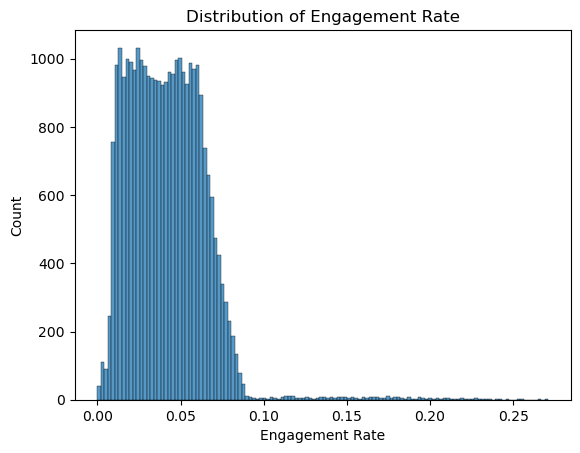

In [27]:
sns.histplot(y)
plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")

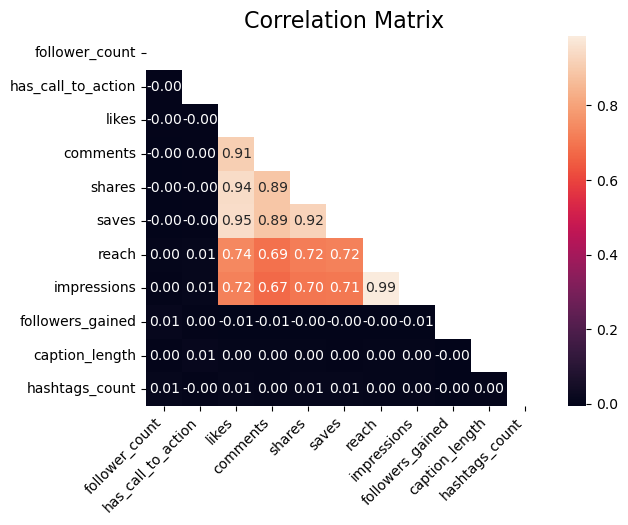

In [28]:

# Create a Correlation Matrix showing relationship between continuous variables
corr_mat=X_df.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt=".2f", mask=mask)
plt.xticks(rotation=45, ha='right')   # Tilt labels for better fit
plt.title("Correlation Matrix", fontsize=16)
plt.show()

From this matrix its shown that Likes, comments, shares, saves are all highly correlated roughly (0.89–0.95) When one goes up, the others almost always go up.This suggests they are all part of the same thing: engagement. 

Reach & impressions vs engagement (likes, comments, etc.) roughly 0.67–0.74 More people seeing your post generally leads to more engagement. But it’s not perfect—content quality still matters.

These variables don’t meaningfully impact others in the dataset: Follower count, Has call to action, Followers gained, Caption length, Hashtags count
Their correlations are close to 0, meaning: Having more followers doesn’t necessarily mean more engagement (in this dataset). Adding hashtags or longer captions doesn’t strongly affect performance. “Call to action” isn’t showing a measurable effect here.

In [30]:
print(type(y))
print(y.head())

<class 'pandas.core.series.Series'>
0    0.0385
1    0.0663
2    0.0531
3    0.0309
4    0.0221
Name: engagement_rate, dtype: float64


In [32]:
from collections import Counter
Counter(y)

Counter({0.048: 67,
         0.0278: 64,
         0.0215: 63,
         0.0143: 62,
         0.0262: 62,
         0.0356: 62,
         0.0444: 62,
         0.0174: 62,
         0.0338: 61,
         0.0346: 61,
         0.0157: 60,
         0.0252: 60,
         0.0474: 60,
         0.0556: 60,
         0.0497: 60,
         0.0523: 60,
         0.0462: 59,
         0.0431: 59,
         0.0272: 59,
         0.0487: 59,
         0.0483: 59,
         0.0293: 59,
         0.0582: 59,
         0.045: 59,
         0.0131: 58,
         0.0557: 58,
         0.054: 58,
         0.0189: 58,
         0.0347: 57,
         0.0452: 57,
         0.0205: 57,
         0.0314: 57,
         0.0329: 57,
         0.0604: 57,
         0.0588: 57,
         0.0267: 57,
         0.0584: 56,
         0.0243: 56,
         0.0167: 56,
         0.0254: 56,
         0.0209: 56,
         0.036: 55,
         0.0515: 55,
         0.0391: 55,
         0.0316: 55,
         0.0606: 55,
         0.0138: 55,
         0.0264: 

In [47]:
# Map y from strings to numbers and extract values
# Calculate the average engagement rate
avg_engagement = y.mean()

# Create binary target: 0 for below or equal to average (not viral), 1 for above average (viral)
y_data = (y > avg_engagement).astype(int).values.ravel()


split the data set

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_data, stratify=y_data, train_size=0.8, random_state=42
)

In [49]:
# Scaling Features using Robust Scaling
rs_scaler = RobustScaler

In [ ]:
# 3. Fit ONLY on the Training data, then transform both
# This ensures the 'Robust' parameters are calculated using ONLY train info
rs_scaler = RobustScaler()
X_train_scaled = rs_scaler.fit_transform(X_train)
X_test_scaled = rs_scaler.transform(X_test) # Use .transform, NOT .fit_transform here

TypeError: TransformerMixin.fit_transform() missing 1 required positional argument: 'X'

In [ ]:
# 4. Optional: Convert back to DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
clf = DecisionTreeRegressor()
clf = clf.fit(X,y)

In [ ]:
predicted = clf.predict(X)
predicted[:100]

array([0.0385, 0.0663, 0.0531, 0.0309, 0.0221, 0.0516, 0.0584, 0.0162,
       0.0657, 0.0401, 0.0243, 0.0546, 0.0226, 0.036 , 0.0637, 0.0417,
       0.0306, 0.0335, 0.014 , 0.0101, 0.0675, 0.041 , 0.0515, 0.015 ,
       0.0177, 0.0728, 0.0384, 0.031 , 0.018 , 0.0074, 0.0389, 0.0397,
       0.0168, 0.0524, 0.0551, 0.0526, 0.0036, 0.0166, 0.0531, 0.0212,
       0.0394, 0.0304, 0.0159, 0.0462, 0.0649, 0.0622, 0.0507, 0.0511,
       0.0374, 0.0256, 0.0511, 0.0126, 0.0583, 0.0185, 0.0317, 0.0322,
       0.0678, 0.0139, 0.0344, 0.0188, 0.0429, 0.0453, 0.0629, 0.0419,
       0.0421, 0.0231, 0.0126, 0.0589, 0.026 , 0.0388, 0.0253, 0.0379,
       0.0351, 0.0583, 0.0431, 0.0526, 0.02  , 0.0317, 0.0227, 0.0633,
       0.0592, 0.0522, 0.0157, 0.0522, 0.0183, 0.0294, 0.0252, 0.0302,
       0.0311, 0.0281, 0.0385, 0.0782, 0.0155, 0.0628, 0.0507, 0.0183,
       0.0565, 0.0164, 0.0143, 0.0146])

In [ ]:
y[:100]

0     0.0385
1     0.0663
2     0.0531
3     0.0309
4     0.0221
       ...  
95    0.0183
96    0.0565
97    0.0164
98    0.0143
99    0.0146
Name: engagement_rate, Length: 100, dtype: float64

In [ ]:
pd.DataFrame({
    "Predicted": predicted[:20],
    "Actual": y[:20].to_numpy()
})

,Predicted,Actual
0,0.0385,0.0385
1,0.0663,0.0663
2,0.0531,0.0531
3,0.0309,0.0309
4,0.0221,0.0221
5,0.0516,0.0516
6,0.0584,0.0584
7,0.0162,0.0162
8,0.0657,0.0657
9,0.0401,0.0401


In [ ]:
clf.score(X,y)

1.0

In [ ]:
# Check for outliers:
def find_outliers(col_name, df):
    # This function identifies the number of outliers in a given column using the Tukey Definition
    # Calculate IQR
    q1=np.percentile(df[col_name], 25)
    q3=np.percentile(df[col_name], 75)
    iqr=q3-q1

    # Calculate Threshold and bounds
    threshold=1.5*iqr
    
    lb=q1-threshold
    ub=q3+threshold

    # Identify outliers
    outliers = np.where((df[col_name] < lb) | (df[col_name] > q3 + ub))

    return len(outliers)

In [ ]:
# Count outliers in each column
for c in X_df.columns:
    num_outliers=find_outliers(c,X_df)
    print(c ,": ",  num_outliers)

follower_count :  1
has_call_to_action :  1
likes :  1
comments :  1
shares :  1
saves :  1
reach :  1
impressions :  1
followers_gained :  1
caption_length :  1
hashtags_count :  1


In [ ]:
from collections import Counter

# Ensure y is a pandas Series holding the engagement labels.
# Accept either 'Engagement_Level' or 'Engagement' column names (compatibility).
if 'y' not in globals() or y is None:
	if 'Engagement_Level' in df.columns:
		y = df['Engagement_Level']
	elif 'Engagement' in df.columns:
		y = df['Engagement']
	else:
		raise KeyError("Neither 'Engagement_Level' nor 'Engagement' found in df columns.")

print(Counter(y))

Counter({0.048: 67, 0.0278: 64, 0.0215: 63, 0.0143: 62, 0.0262: 62, 0.0356: 62, 0.0444: 62, 0.0174: 62, 0.0338: 61, 0.0346: 61, 0.0157: 60, 0.0252: 60, 0.0474: 60, 0.0556: 60, 0.0497: 60, 0.0523: 60, 0.0462: 59, 0.0431: 59, 0.0272: 59, 0.0487: 59, 0.0483: 59, 0.0293: 59, 0.0582: 59, 0.045: 59, 0.0131: 58, 0.0557: 58, 0.054: 58, 0.0189: 58, 0.0347: 57, 0.0452: 57, 0.0205: 57, 0.0314: 57, 0.0329: 57, 0.0604: 57, 0.0588: 57, 0.0267: 57, 0.0584: 56, 0.0243: 56, 0.0167: 56, 0.0254: 56, 0.0209: 56, 0.036: 55, 0.0515: 55, 0.0391: 55, 0.0316: 55, 0.0606: 55, 0.0138: 55, 0.0264: 55, 0.049: 55, 0.0139: 54, 0.0188: 54, 0.0536: 54, 0.0554: 54, 0.0476: 54, 0.0442: 54, 0.0435: 54, 0.0109: 54, 0.0395: 54, 0.0446: 54, 0.0148: 54, 0.0296: 54, 0.0531: 53, 0.0529: 53, 0.0525: 53, 0.0268: 53, 0.0133: 53, 0.023: 53, 0.0477: 53, 0.019: 53, 0.0438: 53, 0.0319: 53, 0.0184: 53, 0.0169: 53, 0.0273: 53, 0.0211: 53, 0.0238: 53, 0.0304: 52, 0.0317: 52, 0.0629: 52, 0.0589: 52, 0.026: 52, 0.0287: 52, 0.0472: 52, 0.0

Part 4: Feature Engineering and Preprocessing

In [ ]:
# Ensure df is available in the notebook; if not, try to load from the CSV used earlier
if 'df' not in globals():
	csv_path = '/Users/bizyc/Downloads/Viral_Social_Media_Trends.csv'
	if os.path.exists(csv_path):
		df = pd.read_csv(csv_path)
	else:
		raise NameError(f"'df' is not defined and CSV not found at: {csv_path}. "
						"Please run the cell that creates 'df' or place the CSV at that path.")

# Map engagement strings to numeric labels robustly using the dataframe
if 'Engagement_Level' in df.columns:
	eng_col = 'Engagement_Level'
elif 'Engagement' in df.columns:
	eng_col = 'Engagement'
else:
	raise KeyError("Neither 'Engagement_Level' nor 'Engagement' found in df columns.")

_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_mapped = df[eng_col].map(_map)

# If any labels were not in the mapping, raise a clear error listing them
if y_mapped.isnull().any():
	unknown = df[eng_col][y_mapped.isnull()].unique()
	raise ValueError(f"Found unmapped engagement labels: {unknown}. Update the mapping accordingly.")

y_data = y_mapped.values

KeyError: "Neither 'Engagement_Level' nor 'Engagement' found in df columns."

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_data, test_size=0.2, random_state=42, stratify=y_data)